In [1]:
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding,SimpleRNN,LSTM,GRU,Dense
import matplotlib.pyplot as plt

In [2]:
vocab_size=10000
maxlen=200

(x_train,y_train),(x_test,y_test)=imdb.load_data(num_words=vocab_size)

# Pad sequences
x_train=pad_sequences(x_train,maxlen=maxlen)
x_test=pad_sequences(x_test,maxlen=maxlen)

print(x_train.shape)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(25000, 200)


In [3]:
rnn_model=Sequential([
Embedding(vocab_size,32,input_length=maxlen),
SimpleRNN(32),
Dense(1,activation='sigmoid')
])

rnn_model.compile(
optimizer='adam',
loss='binary_crossentropy',
metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [4]:
rnn_history=rnn_model.fit(
x_train[:10000],
y_train[:10000],
epochs=3,
validation_data=(x_test[:2000],y_test[:2000])
)

Epoch 1/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 22s 61ms/step - accuracy: 0.5674 - loss: 0.6711 - val_accuracy: 0.7445 - val_loss: 0.5563
Epoch 2/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 18s 59ms/step - accuracy: 0.7911 - loss: 0.4581 - val_accuracy: 0.7915 - val_loss: 0.4729
Epoch 3/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 19s 60ms/step - accuracy: 0.9170 - loss: 0.2146 - val_accuracy: 0.7940 - val_loss: 0.5047


In [5]:
lstm_model=Sequential([
Embedding(vocab_size,32,input_length=maxlen),
LSTM(32),
Dense(1,activation='sigmoid')
])

lstm_model.compile(
optimizer='adam',
loss='binary_crossentropy',
metrics=['accuracy']
)

In [6]:
lstm_history=lstm_model.fit(
x_train[:10000],
y_train[:10000],
epochs=3,
validation_data=(x_test[:2000],y_test[:2000])
)

Epoch 1/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 37s 106ms/step - accuracy: 0.7367 - loss: 0.5171 - val_accuracy: 0.8450 - val_loss: 0.3816
Epoch 2/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 51s 138ms/step - accuracy: 0.8870 - loss: 0.2899 - val_accuracy: 0.8190 - val_loss: 0.3988
Epoch 3/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 76s 119ms/step - accuracy: 0.9280 - loss: 0.2030 - val_accuracy: 0.8320 - val_loss: 0.4141


In [7]:
gru_model=Sequential([
Embedding(vocab_size,32,input_length=maxlen),
GRU(32),
Dense(1,activation='sigmoid')
])

gru_model.compile(
optimizer='adam',
loss='binary_crossentropy',
metrics=['accuracy']
)

In [8]:
gru_history=gru_model.fit(
x_train[:10000],
y_train[:10000],
epochs=3,
validation_data=(x_test[:2000],y_test[:2000])
)

Epoch 1/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 47s 137ms/step - accuracy: 0.6535 - loss: 0.6109 - val_accuracy: 0.8030 - val_loss: 0.4817
Epoch 2/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 39s 125ms/step - accuracy: 0.8554 - loss: 0.3331 - val_accuracy: 0.8350 - val_loss: 0.3760
Epoch 3/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 40s 129ms/step - accuracy: 0.9134 - loss: 0.2189 - val_accuracy: 0.8350 - val_loss: 0.4221


In [9]:
rnn_acc=rnn_model.evaluate(x_test[:2000],y_test[:2000])[1]
lstm_acc=lstm_model.evaluate(x_test[:2000],y_test[:2000])[1]
gru_acc=gru_model.evaluate(x_test[:2000],y_test[:2000])[1]

print("RNN Accuracy:",rnn_acc)
print("LSTM Accuracy:",lstm_acc)
print("GRU Accuracy:",gru_acc)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.7940 - loss: 0.5047
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.8320 - loss: 0.4141
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.8350 - loss: 0.4221
RNN Accuracy: 0.7940000295639038
LSTM Accuracy: 0.8320000171661377
GRU Accuracy: 0.8349999785423279


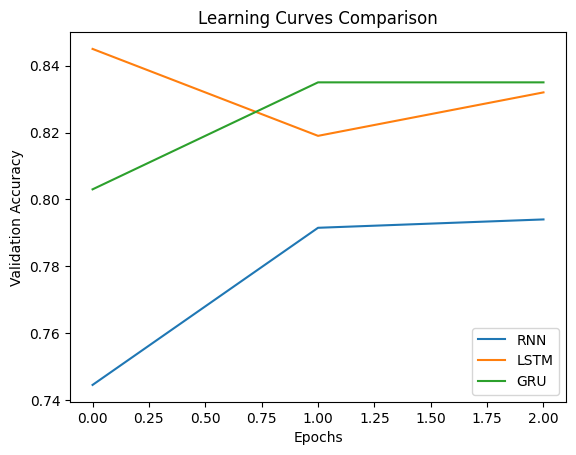

In [10]:
plt.plot(rnn_history.history['val_accuracy'],
label='RNN')

plt.plot(lstm_history.history['val_accuracy'],
label='LSTM')

plt.plot(gru_history.history['val_accuracy'],
label='GRU')

plt.xlabel("Epochs")
plt.ylabel("Validation Accuracy")
plt.title("Learning Curves Comparison")
plt.legend()
plt.show()

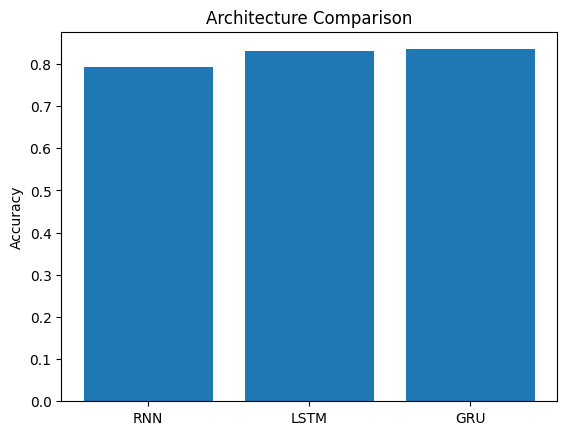

In [11]:
models=['RNN','LSTM','GRU']
accuracy=[rnn_acc,lstm_acc,gru_acc]

plt.bar(models,accuracy)
plt.ylabel("Accuracy")
plt.title("Architecture Comparison")
plt.show()